In [1]:
from src.utils.reproducibility import set_seeds

set_seeds(seed=42)

In [2]:
import os

BASE_PATH = "C:/Users/panaa/Desktop/dipseer"

TRAIN_DIPSEER = os.path.join(BASE_PATH, "train")
VAL_DIPSEER = os.path.join(BASE_PATH, "val")
TEST_DIPSEER = os.path.join(BASE_PATH, "test")

In [3]:
from src.data.loader import build_dataset_with_statistics

split_paths = {
    "train": TRAIN_DIPSEER,
    "val": VAL_DIPSEER,
    "test": TEST_DIPSEER
}

datasets = build_dataset_with_statistics(split_paths)


Building train...
train: 5267 sequences

Attention distribution:
1: 1658
0: 2107
2: 1502

Emotion distribution:
0: 2980
1: 295
3: 1767
2: 225

Building val...
val: 1299 sequences

Attention distribution:
1: 468
0: 224
2: 607

Emotion distribution:
0: 733
1: 181
2: 52
3: 333

Building test...
test: 1259 sequences

Attention distribution:
2: 535
1: 461
0: 263

Emotion distribution:
0: 717
1: 71
3: 354
2: 117


In [4]:
X_train, y_att_train, y_emo_train, stats_train = datasets["train"]
X_val, y_att_val, y_emo_val, stats_val = datasets["val"]
X_test, y_att_test, y_emo_test, stats_test = datasets["test"]

print(X_train.shape)
print(y_emo_train.shape)
print(y_att_train.shape)

(5267, 20, 1434)
(5267,)
(5267,)


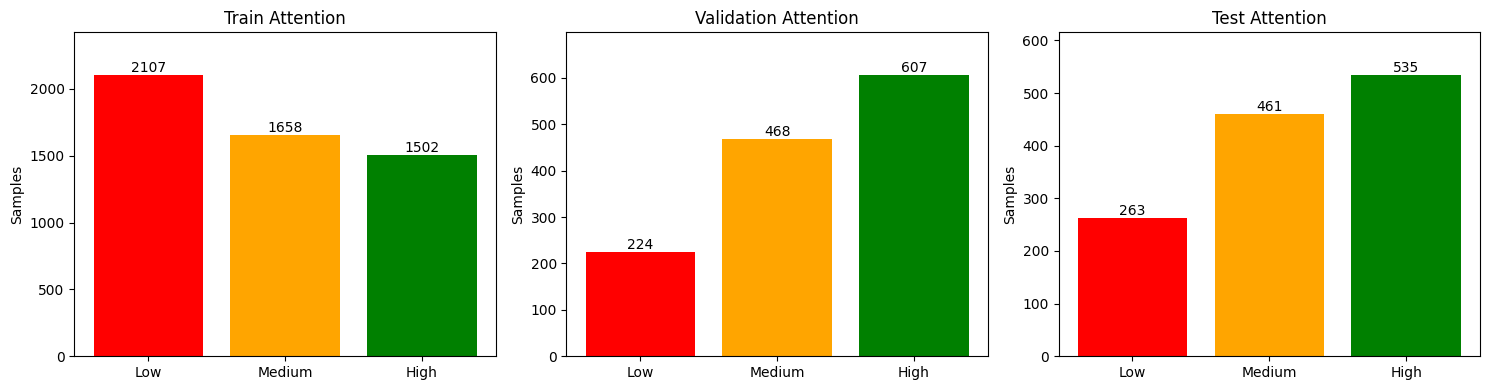

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

ATTENTION_LABELS = ["Low", "Medium", "High"]

def get_attention_distribution(y):
    counts = Counter(y)
    return {i: counts.get(i, 0) for i in range(3)}

def plot_attention_distributions(y_train, y_val, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = ['red', 'orange', 'green']

    for ax, y, name in zip(
        axes,
        [y_train, y_val, y_test],
        ["Train", "Validation", "Test"]
    ):
        dist = get_attention_distribution(y)

        labels = ATTENTION_LABELS
        values = [dist[i] for i in range(3)]

        bars = ax.bar(labels, values, color=colors)

        ax.set_title(f"{name} Attention")
        ax.set_ylabel("Samples")

        ax.set_ylim(0, max(values) * 1.15 if max(values) > 0 else 1)

        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height)}",
                ha='center',
                va='bottom'
            )

    plt.tight_layout()
    plt.show()

plot_attention_distributions(
    y_att_train,
    y_att_val,
    y_att_test
)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_att_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_att_train
)

class_weights = dict(zip(classes, class_weights))
print(class_weights)

{0: 0.8332542319253283, 1: 1.058906312826699, 2: 1.1688859298712828}


In [7]:
from src.models.normal_model_01 import build_model, compile_model, get_callbacks

model = build_model()
compile_model(model)
callbacks = get_callbacks(model_name="best_normal_model_01")

model.summary()

Model: "dipseer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 20, 1434)]        0         
                                                                 
 lstm_1 (LSTM)               (None, 20, 256)           1731584   
                                                                 
 lstm_2 (LSTM)               (None, 128)               197120    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 outputs (Dense)             (None, 3)                 195 

In [8]:
history = model.fit(
    X_train,
    y_att_train,
    validation_data=(X_val, y_att_val),
    class_weight=class_weights,
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/100
330/330 [==============================] - ETA: 0s - loss: 0.9489 - accuracy: 0.5269
Epoch 1: val_loss improved from inf to 1.03977, saving model to E:\student-engagement-analysis-system\ml-model\checkpoints\best_model_01.h5
330/330 [==============================] - 45s 125ms/step - loss: 0.9489 - accuracy: 0.5269 - val_loss: 1.0398 - val_accuracy: 0.3980 - lr: 1.0000e-04
Epoch 2/100
330/330 [==============================] - ETA: 0s - loss: 0.9180 - accuracy: 0.5523
Epoch 2: val_loss did not improve from 1.03977
330/330 [==============================] - 43s 130ms/step - loss: 0.9180 - accuracy: 0.5523 - val_loss: 1.1796 - val_accuracy: 0.3495 - lr: 1.0000e-04
Epoch 3/100
330/330 [==============================] - ETA: 0s - loss: 0.9067 - accuracy: 0.5698
Epoch 3: val_loss did not improve from 1.03977
330/330 [==============================] - 55s 168ms/step - loss: 0.9067 - accuracy: 0.5698 - val_loss: 1.0728 - val_accuracy: 0.4049 - lr: 1.0000e-04
Epoch 4/100
330/330 [=

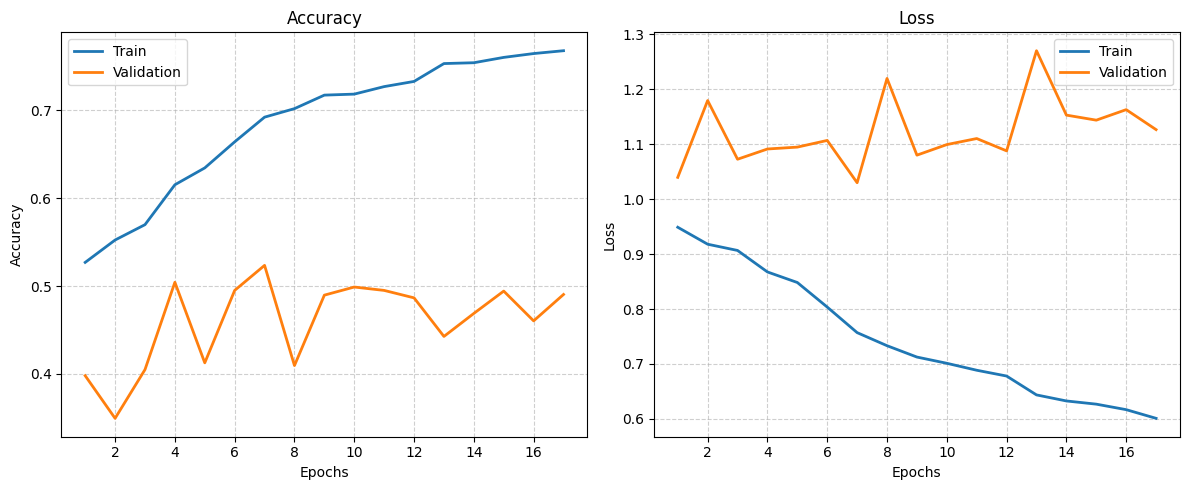

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.style.use('default')
    plt.figure(figsize=(12, 5), facecolor='white')

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train', linewidth=2)
    plt.plot(epochs, val_acc, label='Validation', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation', linewidth=2)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


================ TEST METRICS ================

Accuracy : 0.5949
Macro F1 : 0.5829

=========== Classification Report ===========

              precision    recall  f1-score   support

         Low       0.49      0.54      0.51       263
      Medium       0.63      0.61      0.62       461
        High       0.62      0.61      0.61       535

    accuracy                           0.59      1259
   macro avg       0.58      0.59      0.58      1259
weighted avg       0.60      0.59      0.60      1259



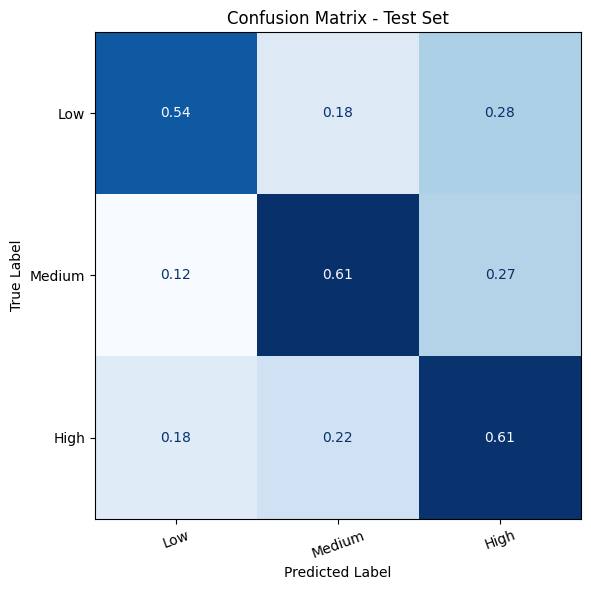

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score)

ATTENTION_LABELS = ["Low", "Medium", "High",]

def evaluate_on_test(model, X_test, y_test, class_names=ATTENTION_LABELS, normalize='true'):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print("\n================ TEST METRICS ================\n")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")


    print("\n=========== Classification Report ===========\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=2))

    cm = confusion_matrix(y_test, y_pred, normalize=normalize)

    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='.2f',
        colorbar=False
    )

    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return y_pred, y_prob

y_pred, y_prob = evaluate_on_test(model, X_test, y_att_test)